<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/MLP_cifar_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt

## Get the Dataset - CIFAR10

In [ ]:
# Load the Dataset
folder = "data"
cifar10 = datasets.CIFAR10(folder, train=True, download=True, transform=transforms.ToTensor())
cifar10_val = datasets.CIFAR10(folder, train=False, download=True, transform = transforms.ToTensor())


100%|██████████| 170M/170M [00:04<00:00, 42.6MB/s]


## Normalize the dataset

In [ ]:
## Convert into Tensors and Normalize it

# Tensors is needed for Pytorch and Normalization helps in training with images

# Stack the whole dataset
imgs = torch.stack([img for img,_ in cifar10],dim=3) # imgs.shape = torch.Size([3, 32, 32, 50000])

# Flatten across H*W*N: reshape by keeping first 3 channels, but flatten all others
imgs_flat = imgs.view(3,-1) # imgs_flat.shape = torch.Size([3, 51200000])

# Mean - To normalize for each channel
mu = imgs_flat.mean(dim=1)

# Std - To normalize for each channel
sigma = imgs_flat.std(dim=1)

cifar10 = datasets.CIFAR10(folder,
                               train = True,
                               download = False,
                               transform = transforms.Compose(
                                   [
                                       transforms.ToTensor(),
                                       transforms.Normalize(mu,sigma)
                                   ]
                               ))
cifar10_val = datasets.CIFAR10(folder,
                               train = False,
                               download = False,
                               transform = transforms.Compose(
                                   [
                                       transforms.ToTensor(),
                                       transforms.Normalize(mu,sigma)
                                   ]
                               ))

# Load the images in batches for training & validation
train_loader = torch.utils.data.DataLoader(cifar10, batch_size = 64, shuffle = False)
val_loader = torch.utils.data.DataLoader(cifar10_val, batch_size = 64, shuffle = False)

## Evaluate the model

In [ ]:
def compute_accuracy(model, loader):
  correct = 0
  total = 0
  with torch.no_grad():
    for imgs, labels in loader:
      outputs = model(imgs.view(imgs.shape[0],-1))
      _, predicted = torch.max(outputs, dim=1)
      correct += int((predicted == labels).sum())
      total += labels.shape[0]
    return correct/total

## Define the Model - MLP

In [ ]:
class MLP(nn.Module):
  def __init__(self, ninputs, nhidden, nclasses):
    super().__init__()
    self.fc1 = nn.Linear(ninputs, nhidden)
    self.fc2 = nn.Linear(nhidden, nclasses)

  def forward(self, x):
    out = F.tanh(self.fc1(x))
    out = self.fc2(out)
    return out # Return logits

## Train the model
Do not run this in case you want to use a pre-trained model

In [ ]:
img, _ = cifar10[0]
# Input features are all the pixels of an image
ninputs = len(img.view(-1))
# Activation Units
nhidden = 512
# Output classes
nclasses = 10

torch.manual_seed(0)
model = MLP(ninputs, nhidden, nclasses)

learning_rate = 1e-2
epochs = 100
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(epochs):
  for imgs, labels in train_loader:
    outputs = model(imgs.view(imgs.shape[0], -1))
    loss = loss_fn(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  acc_val = compute_accuracy(model, val_loader)
  loss_train_batch = float(loss)
  print(f"Epoch {epoch}, Batch Loss {loss_train_batch}, Val accuracy {acc_val}")

model_100 = model

Epoch 0, Batch Loss 2.3553566932678223, Val accuracy 0.3968
Epoch 1, Batch Loss 2.2167117595672607, Val accuracy 0.4182
Epoch 2, Batch Loss 2.1037437915802, Val accuracy 0.4294
Epoch 3, Batch Loss 1.9938362836837769, Val accuracy 0.4342
Epoch 4, Batch Loss 1.8871402740478516, Val accuracy 0.4429
Epoch 5, Batch Loss 1.782072901725769, Val accuracy 0.449
Epoch 6, Batch Loss 1.6761276721954346, Val accuracy 0.451
Epoch 7, Batch Loss 1.568801999092102, Val accuracy 0.4569
Epoch 8, Batch Loss 1.4606086015701294, Val accuracy 0.4627
Epoch 9, Batch Loss 1.3530336618423462, Val accuracy 0.4636
Epoch 10, Batch Loss 1.2483806610107422, Val accuracy 0.4678
Epoch 11, Batch Loss 1.1489940881729126, Val accuracy 0.4725
Epoch 12, Batch Loss 1.0564610958099365, Val accuracy 0.4745
Epoch 13, Batch Loss 0.9714685082435608, Val accuracy 0.4766
Epoch 14, Batch Loss 0.8937382102012634, Val accuracy 0.4826
Epoch 15, Batch Loss 0.8223326206207275, Val accuracy 0.4842
Epoch 16, Batch Loss 0.7564316987991333, 

## Use the weights from saved model
Run this only in case you want to use a pre-trained model

In [ ]:
img, _ = cifar10[0]
# Input features are all the pixels of an image
ninputs = len(img.view(-1))
# Activation Units
nhidden = 512
# Output classes
nclasses = 10

torch.manual_seed(0)
model = MLP(ninputs, nhidden, nclasses)

# Save the model weights in the given path for future re-run
#torch.save(model.state_dict(), "mlp_cifar10_model.pth")

# Load the saved state dictionary into the model
model.load_state_dict(torch.load("mlp_cifar10_model.pth"))

FileNotFoundError: [Errno 2] No such file or directory: 'mlp_cifar10_model.pth'

## Test the results

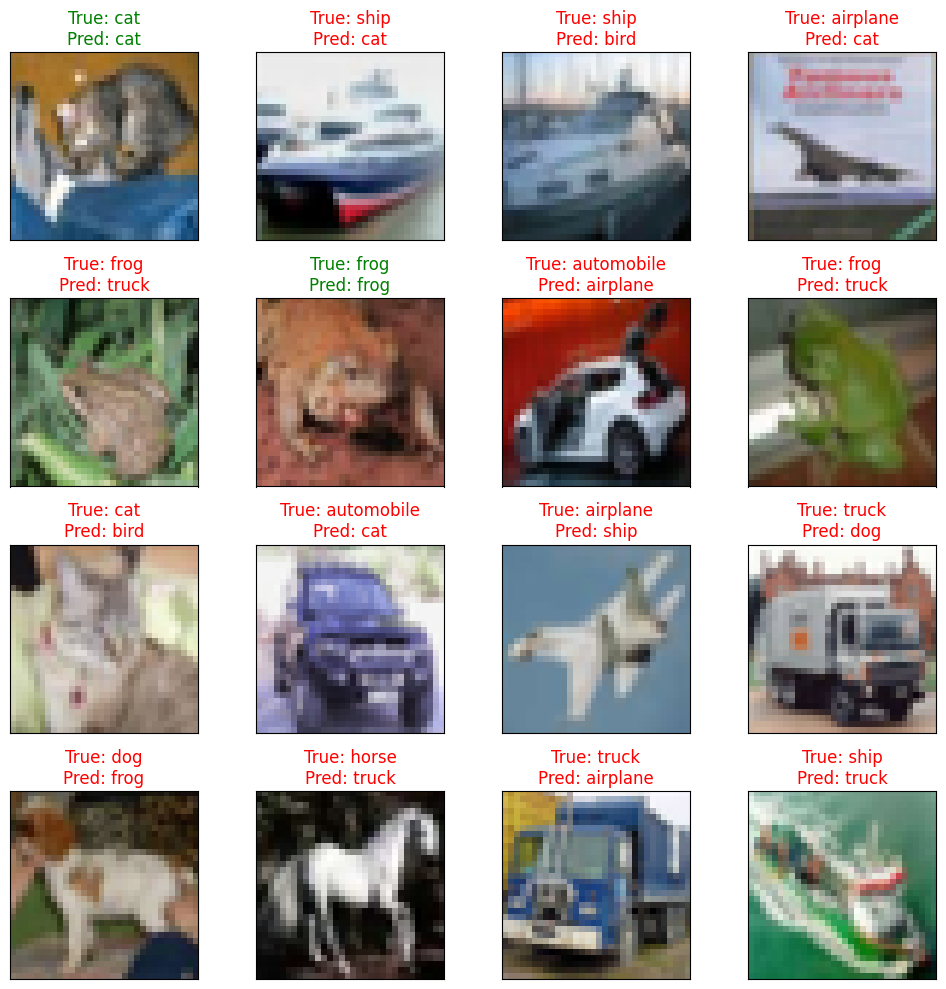

In [ ]:
import numpy as np

# Get a batch of images and labels from the validation loader
images, labels = next(iter(val_loader))

# Make predictions
with torch.no_grad():
    outputs = model(images.view(images.shape[0], -1))
    _, predictions = torch.max(outputs, dim=1)

# Class names for CIFAR10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualize the results
fig = plt.figure(figsize=(10, 10))
for i in range(min(16, len(images))): # Display up to 16 images
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    # Unnormalize the image for display
    img = images[i].numpy().transpose(1, 2, 0) * sigma.numpy() + mu.numpy()
    img = np.clip(img, 0, 1) # Clip values to be between 0 and 1
    ax.imshow(img)
    color = "green" if predictions[i] == labels[i] else "red"
    ax.set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[predictions[i]]}", color=color)

plt.tight_layout()
plt.show()